In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ML Models
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score, roc_curve)
from sklearn.preprocessing import StandardScaler

# XAI
import shap
import lime
import lime.lime_tabular

print("All libraries loaded successfully!")

All libraries loaded successfully!


c:\Users\Lenovo\Phishing-XAI-Model\phishing_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:

df = pd.read_csv('phishing_site_urls.csv') # loading dataset 

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (549346, 2)

First 5 rows:


,URL,Label
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,bad
1,www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...,bad
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,bad
3,mail.printakid.com/www.online.americanexpress....,bad
4,thewhiskeydregs.com/wp-content/themes/widescre...,bad


In [3]:
print("Shape:", df.shape)
print("\nColumn names:", df.columns.tolist())
print("\nMissing values:")
print(df.isnull().sum())
print("\nClass distribution:")
print(df['Label'].value_counts())
print("\nClass percentage:")
print(df['Label'].value_counts(normalize=True) * 100)

Shape: (549346, 2)

Column names: ['URL', 'Label']

Missing values:
URL      0
Label    0
dtype: int64

Class distribution:
Label
good    392924
bad     156422
Name: count, dtype: int64

Class percentage:
Label
good    71.525778
bad     28.474222
Name: proportion, dtype: float64


In [4]:
import re

def extract_features(url):
    return {
        'url_length': len(url),              
        'num_dots': url.count('.'),           
        'num_hyphens': url.count('-'),        
        'num_underscores': url.count('_'),    
        'num_slashes': url.count('/'),        
        'num_at': url.count('@'),             
        'num_question': url.count('?'),       
        'num_equal': url.count('='),          
        'num_digits': sum(c.isdigit() for c in url),  
        'has_https': 1 if url.startswith('https') else 0,  
        'has_http': 1 if url.startswith('http') else 0,    
        'has_ip': 1 if re.search(r'\d+\.\d+\.\d+\.\d+', url) else 0, 
        'num_subdomains': url.count('.') - 1,  
        'url_depth': url.count('/'),             
        'has_suspicious_words': 1 if any(word in url.lower() for word in 
            ['login', 'verify', 'secure', 'account', 'update', 
             'banking', 'confirm', 'paypal', 'ebay']) else 0,  
    }

print("Extracting features")
features_df = pd.DataFrame(df['URL'].apply(extract_features).tolist())

# Convert labels: good=0, bad=1 
features_df['Label'] = df['Label'].map({'good': 0, 'bad': 1})

print("Features extracted!")
print("\nShape:", features_df.shape)
features_df.head()

Extracting features
Features extracted!

Shape: (549346, 16)


,url_length,num_dots,num_hyphens,num_underscores,num_slashes,num_at,num_question,num_equal,num_digits,has_https,has_http,has_ip,num_subdomains,url_depth,has_suspicious_words,Label
0,225,6,4,4,10,0,1,4,58,0,0,0,5,10,1,1
1,81,5,2,1,4,0,0,2,1,0,0,0,4,4,1,1
2,177,7,1,0,11,0,0,0,47,0,0,0,6,11,1,1
3,60,6,0,0,2,0,0,0,0,0,0,0,5,2,0,1
4,116,1,1,0,10,0,1,0,21,0,0,0,0,10,0,1


In [5]:
X = features_df.drop('Label', axis=1)  # everything except label
y = features_df['Label']               # only the label (0=good, 1=bad)

# Split into 80:20

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

# Scaling for Logistic Regression

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling done!")

Training samples: 439476
Testing samples: 109870
Scaling done!


In [6]:
# logistic regression

print("Training Logistic Regression")

lr_model = LogisticRegression(
    max_iter=1000,        
    class_weight='balanced',  # handles class imbalance automatically
    random_state=42
)
lr_model.fit(X_train_scaled, y_train)
print("Logistic Regression trained")

Training Logistic Regression
Logistic Regression trained


In [7]:
# random forest (primary classifier) 
print("Training Random Forest")

rf_model = RandomForestClassifier(
    n_estimators=100,         # 100 decision trees
    class_weight='balanced',  # handles class imbalance
    random_state=42,
    n_jobs=-1                 
)
rf_model.fit(X_train, y_train)
print("Random Forest trained")

Training Random Forest
Random Forest trained


logistic regression results

Classification Report:
              precision    recall  f1-score   support

    Good (0)       0.82      0.80      0.81     78585
     Bad (1)       0.53      0.56      0.54     31285

    accuracy                           0.73    109870
   macro avg       0.67      0.68      0.68    109870
weighted avg       0.74      0.73      0.73    109870

ROC-AUC Score: 0.6782994136469808


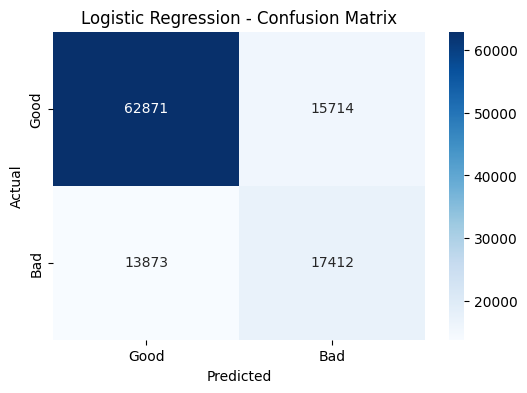

In [8]:
# logistic regression testing 
y_pred_lr = lr_model.predict(X_test_scaled)


print("logistic regression results")


print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, 
      target_names=['Good (0)', 'Bad (1)']))

# ROC-AUC Score — closer to 1.0 = better model
print("ROC-AUC Score:", roc_auc_score(y_test, y_pred_lr))

cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(6,4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Good', 'Bad'],
            yticklabels=['Good', 'Bad'])
plt.title('Logistic Regression - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

random forest results

Classification Report:
              precision    recall  f1-score   support

    Good (0)       0.91      0.88      0.89     78585
     Bad (1)       0.72      0.78      0.75     31285

    accuracy                           0.85    109870
   macro avg       0.81      0.83      0.82    109870
weighted avg       0.86      0.85      0.85    109870

ROC-AUC Score: 0.829433923615527


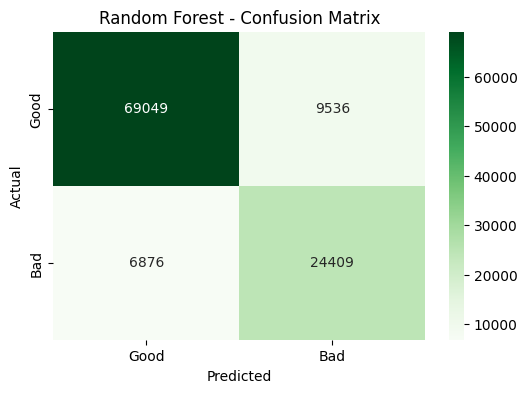

In [9]:
# random forest testiing
y_pred_rf = rf_model.predict(X_test)


print("random forest results")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf,
      target_names=['Good (0)', 'Bad (1)']))

print("ROC-AUC Score:", roc_auc_score(y_test, y_pred_rf))

cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Good', 'Bad'],
            yticklabels=['Good', 'Bad'])
plt.title('Random Forest - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

Calculating SHAP values
SHAP values calculated!


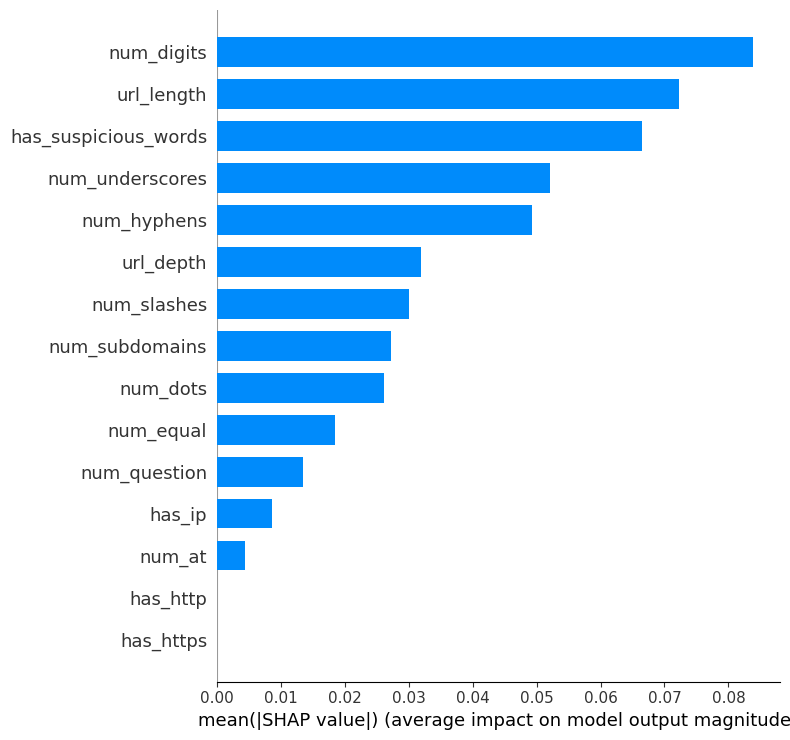

In [10]:
print("Calculating SHAP values")

X_sample = X_test.sample(100, random_state=42)

explainer = shap.TreeExplainer(rf_model, feature_perturbation="tree_path_dependent")
shap_values = explainer.shap_values(X_sample, check_additivity=False)

print("SHAP values calculated!")

shap.summary_plot(shap_values[:,:,1], X_sample,
plot_type="bar")
plt.show()

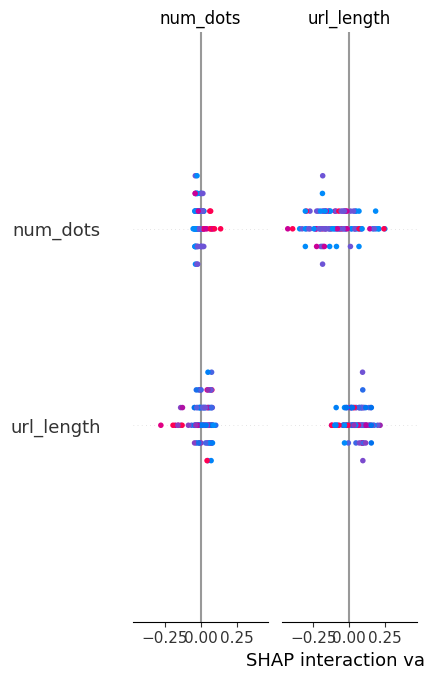

In [11]:
# Red = pushes towards phishing (bad)
# Blue = pushes towards legitimate (good)
shap.summary_plot(shap_values, X_sample)
plt.show()

LIME explanation generated!

URL being explained:
www.attivita-antroposofiche-roma.org/kw9qzt


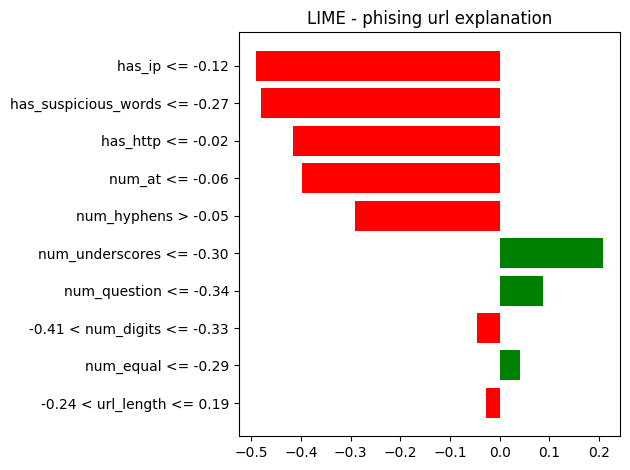

In [12]:
import lime
import lime.lime_tabular

lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train_scaled),
    feature_names=X.columns.tolist(),
    class_names=['Good', 'Bad'],
    mode='classification'
)

bad_url_idx = y_test[y_test == 1].index[0]
bad_url_pos = X_test.index.get_loc(bad_url_idx)
instance = X_test_scaled[bad_url_pos]

# Generate explanation
explanation = lime_explainer.explain_instance(
    instance,
    lr_model.predict_proba,
    num_features=10
)

print("LIME explanation generated!")
print("\nURL being explained:")
print(df['URL'].iloc[bad_url_idx])

explanation.as_pyplot_figure()
plt.title("LIME - phising url explanation")
plt.tight_layout()
plt.show()

MODEL COMPARISON TABLE
              Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
Logistic Regression  0.730709   0.525629 0.556561  0.540653 0.678299
      Random Forest  0.850623   0.719075 0.780214  0.748398 0.829434


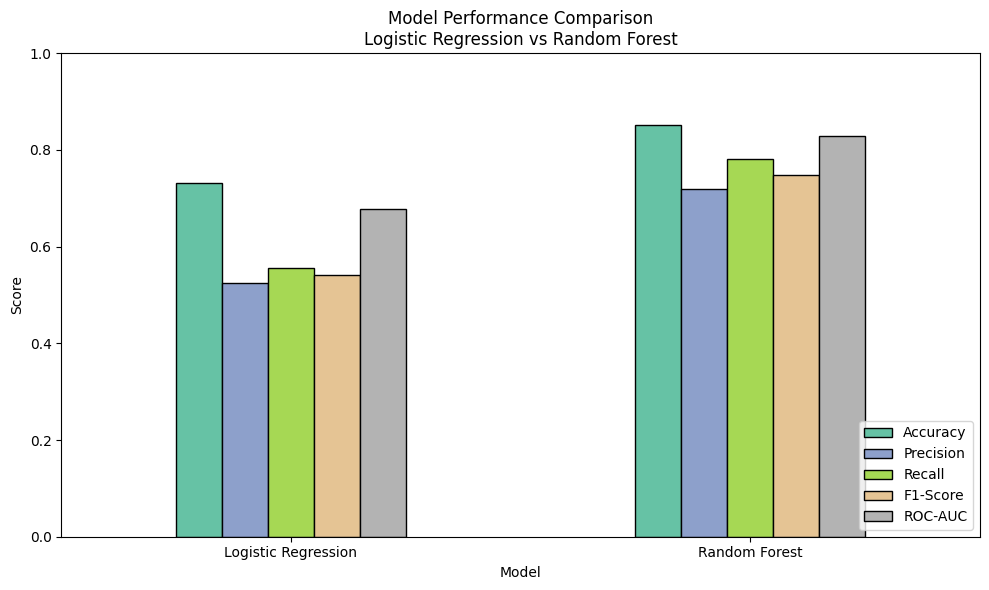

In [13]:
# model comparasion
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = {
'Model': ['Logistic Regression', 'Random Forest'],
'Accuracy': [accuracy_score(y_test, y_pred_lr),accuracy_score(y_test, y_pred_rf)],
'Precision': [precision_score(y_test, y_pred_lr),precision_score(y_test, y_pred_rf)],
'Recall': [recall_score(y_test, y_pred_lr),recall_score(y_test, y_pred_rf)],
'F1-Score': [f1_score(y_test, y_pred_lr),f1_score(y_test, y_pred_rf)],
'ROC-AUC': [roc_auc_score(y_test, y_pred_lr),roc_auc_score(y_test, y_pred_rf)]
}

results_df = pd.DataFrame(results)
print("MODEL COMPARISON TABLE")
print(results_df.to_string(index=False))

# Plot comparison
results_df.set_index('Model').plot(kind='bar', figsize=(10,6), colormap='Set2', edgecolor='black')
plt.title('Model Performance Comparison\nLogistic Regression vs Random Forest')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [14]:
import pickle

with open('random_forest_model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)

with open('logistic_regression_model.pkl', 'wb') as f:
    pickle.dump(lr_model, f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open('feature_names.pkl', 'wb') as f:
    pickle.dump(X.columns.tolist(), f)

print("All 4 files saved!")


All 4 files saved!


In [15]:
from sklearn.utils import resample

# Separate good and bad
df_good = features_df[features_df['Label'] == 0]
df_bad  = features_df[features_df['Label'] == 1]

print(f"Good URLs: {len(df_good)}")
print(f"Bad URLs:  {len(df_bad)}")

df_good_balanced = resample(df_good, replace=False,n_samples=len(df_bad),random_state=42)

# Combine into balanced dataset
df_balanced = pd.concat([df_good_balanced, df_bad])
df_balanced = df_balanced.sample(frac=1, random_state=42)  # shuffle

print(f"\nBalanced dataset size: {len(df_balanced)}")
print(df_balanced['Label'].value_counts())

Good URLs: 392924
Bad URLs:  156422

Balanced dataset size: 312844
Label
1    156422
0    156422
Name: count, dtype: int64


In [16]:
X_bal = df_balanced.drop('Label', axis=1)
y_bal = df_balanced['Label']

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_bal, y_bal, test_size=0.2, random_state=42, stratify=y_bal
)

# Scale for LR
scaler_b = StandardScaler()
X_train_b_scaled = scaler_b.fit_transform(X_train_b)
X_test_b_scaled  = scaler_b.transform(X_test_b)

# Retrain Random Forest
print("Training Random Forest")
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_b, y_train_b)
print("Random Forest done!")

# Retrain Logistic Regression
print("Training Logistic Regression")
lr_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    C=0.1,
    random_state=42
)
lr_model.fit(X_train_b_scaled, y_train_b)
print("Logistic Regression done!")

Training Random Forest
Random Forest done!
Training Logistic Regression
Logistic Regression done!


In [17]:
from sklearn.metrics import classification_report

y_pred_rf_b = rf_model.predict(X_test_b)
y_pred_lr_b = lr_model.predict(X_test_b_scaled)

print("RANDOM FOREST:")
print(classification_report(y_test_b, y_pred_rf_b, target_names=['Good', 'Bad']))

print("LOGISTIC REGRESSION:")
print(classification_report(y_test_b, y_pred_lr_b, target_names=['Good', 'Bad']))

RANDOM FOREST:
              precision    recall  f1-score   support

        Good       0.81      0.86      0.83     31285
         Bad       0.85      0.79      0.82     31284

    accuracy                           0.83     62569
   macro avg       0.83      0.83      0.83     62569
weighted avg       0.83      0.83      0.83     62569

LOGISTIC REGRESSION:
              precision    recall  f1-score   support

        Good       0.64      0.80      0.71     31285
         Bad       0.73      0.56      0.63     31284

    accuracy                           0.68     62569
   macro avg       0.69      0.68      0.67     62569
weighted avg       0.69      0.68      0.67     62569



In [18]:
import pickle

with open('random_forest_model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)

with open('logistic_regression_model.pkl', 'wb') as f:
    pickle.dump(lr_model, f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler_b, f)

with open('feature_names.pkl', 'wb') as f:
    pickle.dump(X_bal.columns.tolist(), f)

print("New balanced models saved!")

New balanced models saved!


In [19]:
# Better feature extraction with domain-based features
import re
from urllib.parse import urlparse

# List of known legitimate domains
TRUSTED_DOMAINS = [
    'google.com', 'facebook.com', 'youtube.com', 'twitter.com',
    'linkedin.com', 'instagram.com', 'microsoft.com', 'apple.com',
    'amazon.com', 'netflix.com', 'github.com', 'wikipedia.org',
    'reddit.com', 'whatsapp.com', 'zoom.us', 'dropbox.com',
    'adobe.com', 'spotify.com', 'paypal.com', 'ebay.com',
    'yahoo.com', 'bing.com', 'office.com', 'live.com',
    'outlook.com', 'gmail.com', 'icloud.com', 'stackoverflow.com'
]

def extract_features_v2(url):
    try:
        parsed = urlparse(url if url.startswith('http') else 'http://' + url)
        domain = parsed.netloc.lower().replace('www.', '')
    except:
        domain = ''

    # Check if domain is trusted
    is_trusted = 1 if any(domain == td or domain.endswith('.' + td) 
                          for td in TRUSTED_DOMAINS) else 0

    return {
        'url_length'           : len(url),
        'num_dots'             : url.count('.'),
        'num_hyphens'          : url.count('-'),
        'num_underscores'      : url.count('_'),
        'num_slashes'          : url.count('/'),
        'num_at'               : url.count('@'),
        'num_question'         : url.count('?'),
        'num_equal'            : url.count('='),
        'num_digits'           : sum(c.isdigit() for c in url),
        'has_https'            : 1 if url.startswith('https') else 0,
        'has_http'             : 1 if url.startswith('http') else 0,
        'has_ip'               : 1 if re.search(r'\d+\.\d+\.\d+\.\d+', url) else 0,
        'num_subdomains'       : url.count('.') - 1,
        'url_depth'            : url.count('/'),
        'has_suspicious_words' : 1 if any(w in url.lower() for w in
                                   ['login','verify','secure','account','update',
                                    'banking','confirm','paypal','ebay']) else 0,
        'is_trusted_domain'    : is_trusted,  # NEW FEATURE!
    }

# Test it
print(extract_features_v2("https://www.linkedin.com"))
print(extract_features_v2("http://paypal-login.verify.com"))

{'url_length': 24, 'num_dots': 2, 'num_hyphens': 0, 'num_underscores': 0, 'num_slashes': 2, 'num_at': 0, 'num_question': 0, 'num_equal': 0, 'num_digits': 0, 'has_https': 1, 'has_http': 1, 'has_ip': 0, 'num_subdomains': 1, 'url_depth': 2, 'has_suspicious_words': 0, 'is_trusted_domain': 1}
{'url_length': 30, 'num_dots': 2, 'num_hyphens': 1, 'num_underscores': 0, 'num_slashes': 2, 'num_at': 0, 'num_question': 0, 'num_equal': 0, 'num_digits': 0, 'has_https': 0, 'has_http': 1, 'has_ip': 0, 'num_subdomains': 1, 'url_depth': 2, 'has_suspicious_words': 1, 'is_trusted_domain': 0}


In [21]:
# Re-extract ALL features using new function
print("Re-extracting features with new trusted domain feature")
features_df_v2 = pd.DataFrame(df['URL'].apply(extract_features_v2).tolist())
features_df_v2['Label'] = df['Label'].map({'good': 0, 'bad': 1})
print("Done!")
print(features_df_v2.shape)
features_df_v2.head()

Re-extracting features with new trusted domain feature
Done!
(549346, 17)


,url_length,num_dots,num_hyphens,num_underscores,num_slashes,num_at,num_question,num_equal,num_digits,has_https,has_http,has_ip,num_subdomains,url_depth,has_suspicious_words,is_trusted_domain,Label
0,225,6,4,4,10,0,1,4,58,0,0,0,5,10,1,0,1
1,81,5,2,1,4,0,0,2,1,0,0,0,4,4,1,0,1
2,177,7,1,0,11,0,0,0,47,0,0,0,6,11,1,0,1
3,60,6,0,0,2,0,0,0,0,0,0,0,5,2,0,0,1
4,116,1,1,0,10,0,1,0,21,0,0,0,0,10,0,0,1


In [22]:
# Balance the new dataset
df_good_v2 = features_df_v2[features_df_v2['Label'] == 0]
df_bad_v2  = features_df_v2[features_df_v2['Label'] == 1]

df_good_bal = resample(df_good_v2, replace=False, 
                        n_samples=len(df_bad_v2), random_state=42)
df_balanced_v2 = pd.concat([df_good_bal, df_bad_v2]).sample(frac=1, random_state=42)

X_v2 = df_balanced_v2.drop('Label', axis=1)
y_v2 = df_balanced_v2['Label']

X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(
    X_v2, y_v2, test_size=0.2, random_state=42, stratify=y_v2
)

scaler_v2 = StandardScaler()
X_train_v2_scaled = scaler_v2.fit_transform(X_train_v2)
X_test_v2_scaled  = scaler_v2.transform(X_test_v2)

print("Training Random Forest v2")
rf_model = RandomForestClassifier(
    n_estimators=200, max_depth=20,
    class_weight='balanced', random_state=42, n_jobs=-1
)
rf_model.fit(X_train_v2, y_train_v2)
print("Random Forest v2 done!")

print("Training Logistic Regression v2")
lr_model = LogisticRegression(
    max_iter=1000, class_weight='balanced',
    C=0.1, random_state=42
)
lr_model.fit(X_train_v2_scaled, y_train_v2)
print("Logistic Regression v2 done!")

# Evaluate
y_pred_rf_v2 = rf_model.predict(X_test_v2)
y_pred_lr_v2 = lr_model.predict(X_test_v2_scaled)

print("\nRANDOM FOREST v2:")
print(classification_report(y_test_v2, y_pred_rf_v2, target_names=['Good', 'Bad']))

print("LOGISTIC REGRESSION v2:")
print(classification_report(y_test_v2, y_pred_lr_v2, target_names=['Good', 'Bad']))

Training Random Forest v2
Random Forest v2 done!
Training Logistic Regression v2
Logistic Regression v2 done!

RANDOM FOREST v2:
              precision    recall  f1-score   support

        Good       0.82      0.86      0.84     31285
         Bad       0.85      0.81      0.83     31284

    accuracy                           0.83     62569
   macro avg       0.83      0.83      0.83     62569
weighted avg       0.83      0.83      0.83     62569

LOGISTIC REGRESSION v2:
              precision    recall  f1-score   support

        Good       0.66      0.74      0.70     31285
         Bad       0.70      0.62      0.66     31284

    accuracy                           0.68     62569
   macro avg       0.68      0.68      0.68     62569
weighted avg       0.68      0.68      0.68     62569



In [23]:
with open('random_forest_model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)

with open('logistic_regression_model.pkl', 'wb') as f:
    pickle.dump(lr_model, f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler_v2, f)

with open('feature_names.pkl', 'wb') as f:
    pickle.dump(X_v2.columns.tolist(), f)

print("Final models saved!")

Final models saved!


In [24]:
lr_model = LogisticRegression(
    max_iter=2000,
    class_weight='balanced',
    C=1.0,        # increased from 0.1
    random_state=42
)
lr_model.fit(X_train_v2_scaled, y_train_v2)

with open('logistic_regression_model.pkl', 'wb') as f:
    pickle.dump(lr_model, f)

print("LR retrained and saved!")

LR retrained and saved!


In [25]:
with open('logistic_regression_model.pkl', 'wb') as f:
    pickle.dump(lr_model, f)

print("New LR model saved!")

New LR model saved!
